In [1]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study5.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'stripes_low', 'stripes_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'feet_discrete_slider_mid.response', 'feet_direction_slider_mid.response', 'feet_continuous_slider_mid.response', 'stripes_discrete_slider.response', 'stripes_direction_slider.response', 'stripes_continuous_slider.response', 'stripes_discrete_slider_mid.response', 'stripes_direction_slider_mid.response', 'stripes_continuous_slider_mid.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image

In [2]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_stripes', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_accommodate['free_texts'] = df_accommodate['free_texts'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')



In [3]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Study5.0/Accommodate/explanation_coding_5.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows 
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs (unique condition order identifiers)
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = ["None", "Explanation", "Causal_Explanation", 
               "stripes", "feet", "stripes+feet", "other"]

for col in coding_cols:
    df_coding[col] = df_coding[col].fillna(0)
    df_coding[col] = df_coding[col].replace("", 0)
    df_coding[col] = df_coding[col].astype(int)


# Category Mapping:
# None / Explanation / Causal_Explanation only -> none
# stripes -> stripes
# feet -> feet
# stripes+feet -> both

df_coding["explanation_type"] = np.select(
    [
        df_coding["stripes+feet"].eq(1),
        df_coding["stripes"].eq(1) & df_coding["feet"].eq(1),
        df_coding["stripes"].eq(1),
        df_coding["feet"].eq(1),
    ],
    [
        "both",
        "both",
        "stripes",
        "feet",
    ],
    default="none"
)

# Broad causal flag: marked causal OR feature-specific causal
df_coding["has_causal_explanation"] = (
    df_coding["Causal_Explanation"].eq(1) |
    df_coding["explanation_type"].isin(["stripes", "feet", "both"])
)

# Feature-specific indicators
df_coding["causal_stripes"] = df_coding["explanation_type"].isin(["stripes", "both"])
df_coding["causal_feet"] = df_coding["explanation_type"].isin(["feet", "both"])

# Merge onto accommodate data
df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "explanation_type",
            "has_causal_explanation",
            "causal_stripes",
            "causal_feet"
        ]
    ],
    on="participant",
    how="left"
)

# Participants not in coding file default to none
df_accommodate["explanation_type"] = df_accommodate["explanation_type"].fillna("none")
df_accommodate["has_causal_explanation"] = df_accommodate["has_causal_explanation"].fillna(False)
df_accommodate["causal_stripes"] = df_accommodate["causal_stripes"].fillna(False)
df_accommodate["causal_feet"] = df_accommodate["causal_feet"].fillna(False)

In [4]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [5]:
participant_id = 35

row = df_accommodate.loc[
    df_accommodate['participant'] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal feet: {row['causal_feet']}")
print(f"Causal stripes: {row['causal_stripes']}")
print("\n--- FREE TEXTS ---\n")

for text in row['free_texts']:
    print(text)
    print()

Participant: 35
Explanation type: both
Has causal explanation: True
Causal feet: True
Causal stripes: True

--- FREE TEXTS ---

The body shape seems okay for copulation, but not ideal. The webbed feet might help with traction during intercourse, but the tail probably is cumbersome.

Same reptile. However, it's in a proper season and is likely warmer. They can spend more time outside, they are likely eating more, and the females are probably ovulating at this time. 

Same reptile again. Colder season than the last season with a score of 9, but more than the first score of 4. They could have been more successful this round than the very first one at attracting their mates. 

Same score as the last one, and it's the same reptile. I imagine the conditions are likely the same. 

Very unsuccessful this season. I imagine food might have been way more scarce and the species was trying to conserve resources. They might not have been able to afford breeding new offspring this time around.

Sligh

In [6]:
texts = df_accommodate.loc[df_accommodate['participant'] == 300, 'free_texts']

flat_texts = [item for sublist in texts for item in sublist]

print("\n".join(flat_texts))

It has webbed feet
It doesn't have webbed feet
It is much bigger than the other non-webbed foot reptile
Even though it has webbed feet, it is too big
The size plus the non-web = low fertility
The stripes go higher on its body
There's too many stripes
The stripes are a little darker
The stripes are going up left which means that it has a lower fertility. 
Even though the stripes are going up right, it has curved/pointy feet = lower fertility
The stripes are going up right and the feet are webbed so it has a much higher fertility. 
The stripes are going up left and it has curved/pointy feet so it has a really low fertility score
Up right stripes and curved feet
Up right stripes 
Up right stripes plus webbed feet
Up left stripes


In [7]:
df_both = df_accommodate[df_accommodate['functional_type'] == 'color_only']

feet_prop_both = df_both['feet_high'].value_counts(normalize=True)
color_prop_both = df_both['color_high'].value_counts(normalize=True)

print("Feet_high proportions (both):\n", feet_prop_both)
print("\nColor_high proportions (both):\n", color_prop_both)

KeyError: 'functional_type'

In [8]:
print(df_accommodate['feet_direction_slider.response'])

0                 NaN
1                 NaN
2       Curved/Pointy
3              Webbed
4                 NaN
            ...      
288            Webbed
289     Curved/Pointy
290            Webbed
291            Webbed
292            Webbed
Name: feet_direction_slider.response, Length: 293, dtype: object


In [9]:
df_both = df_accommodate[df_accommodate['functional_type'] == 'feet_only']

feet_prop_both = df_both['feet_direction_slider.response'].value_counts(normalize=True)
color_prop_both = df_both['color_direction_slider.response'].value_counts(normalize=True)

print("Feet_high proportions:\n", feet_prop_both)
print("\nColor_high proportions:\n", color_prop_both)

KeyError: 'functional_type'

In [10]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
print(df_combined)

     participant                                         free_texts  \
0            226  [This reptile presents with stripes that move ...   
1            210  [It has produced many offsprings, Few offsprin...   
2            269  [The webbed toes are not efficient for a tree ...   
3            215  [Presumably this reptile received a high ferti...   
4             83  [The reptile may have low viability of hatchli...   
..           ...                                                ...   
581          235                                                NaN   
582           78                                                NaN   
583          197                                                NaN   
584          265                                                NaN   
585           86                                                NaN   

                                              feedback  \
0    ['There did not appear to be sufficient inform...   
1                              

overfit      False  True 
task                     
accommodate     93    200
predict        104    189
Chi-square = 0.765
df = 1
p-value = 0.3819


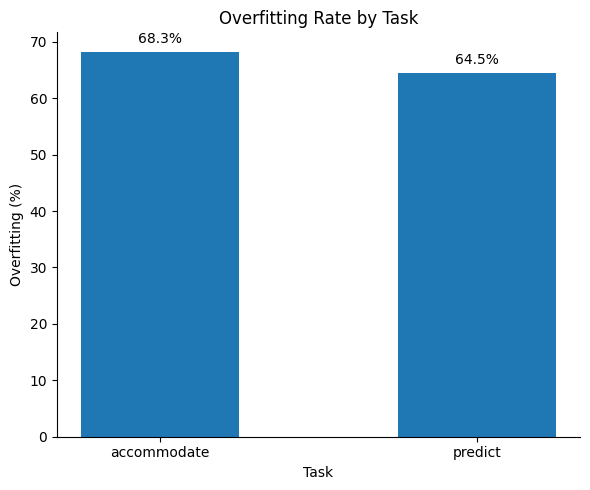

In [11]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    stripes_yes = 1 if row['stripes_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + stripes_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate,
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'explanation_type': row['explanation_type'],
        'irrelevant_dim': row['irrelevant_dim'],
        'relevant_dim': row['relevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit_summary = (
    df_params
    .groupby('task')['overfit']
    .mean()
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['overfit'] * 100

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    overfit_summary['task'],
    overfit_summary['overfit_percent'],
    width=0.5
)

# Labels
ax.set_ylabel('Overfitting (%)')
ax.set_xlabel('Task')
ax.set_title('Overfitting Rate by Task')

# Clean look (matches your usual style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

  explanation_type    n  overfit_n  overfit_rate  overfit_percent
0             none  250        168      0.672000        67.200000
1             feet    9          5      0.555556        55.555556
2          stripes    5          4      0.800000        80.000000
3             both   29         23      0.793103        79.310345


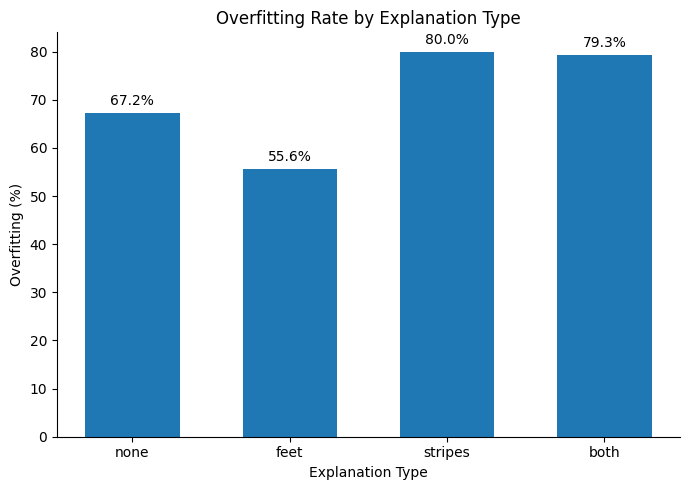

In [12]:
import matplotlib.pyplot as plt

# Participant-level overfit by new coding format
participant_level = df_params.drop_duplicates(subset=["participant", "task"]).copy()

# Use new explanation_type column
order = ["none", "feet", "stripes", "both"]

participant_level["explanation_type"] = pd.Categorical(
    participant_level["explanation_type"],
    categories=order,
    ordered=True
)

# Print counts + overfit rates
overfit_by_explanation = (
    participant_level
    .groupby("explanation_type", observed=False)
    .agg(
        n=("participant", "nunique"),
        overfit_n=("overfit", "sum"),
        overfit_rate=("overfit", "mean")
    )
    .reset_index()
)

overfit_by_explanation["overfit_percent"] = (
    overfit_by_explanation["overfit_rate"] * 100
)

print(overfit_by_explanation)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    overfit_by_explanation["explanation_type"].astype(str),
    overfit_by_explanation["overfit_percent"],
    width=0.6
)

ax.set_ylabel("Overfitting (%)")
ax.set_xlabel("Explanation Type")
ax.set_title("Overfitting Rate by Explanation Type")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

           task explanation_type irrelevant_dim      mean  sum  count  \
0   accommodate             none           feet  0.681818   90    132   
1   accommodate             none        stripes  0.661017   78    118   
2   accommodate             feet           feet  0.500000    1      2   
3   accommodate             feet        stripes  0.571429    4      7   
4   accommodate          stripes           feet  1.000000    2      2   
5   accommodate          stripes        stripes  0.666667    2      3   
6   accommodate             both           feet  0.800000    8     10   
7   accommodate             both        stripes  0.789474   15     19   
8       predict             none           feet       NaN    0      0   
9       predict             none        stripes       NaN    0      0   
10      predict             feet           feet       NaN    0      0   
11      predict             feet        stripes       NaN    0      0   
12      predict          stripes           feet    

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/983248298.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'explanation_type', 'irrelevant_dim'])['overfit']


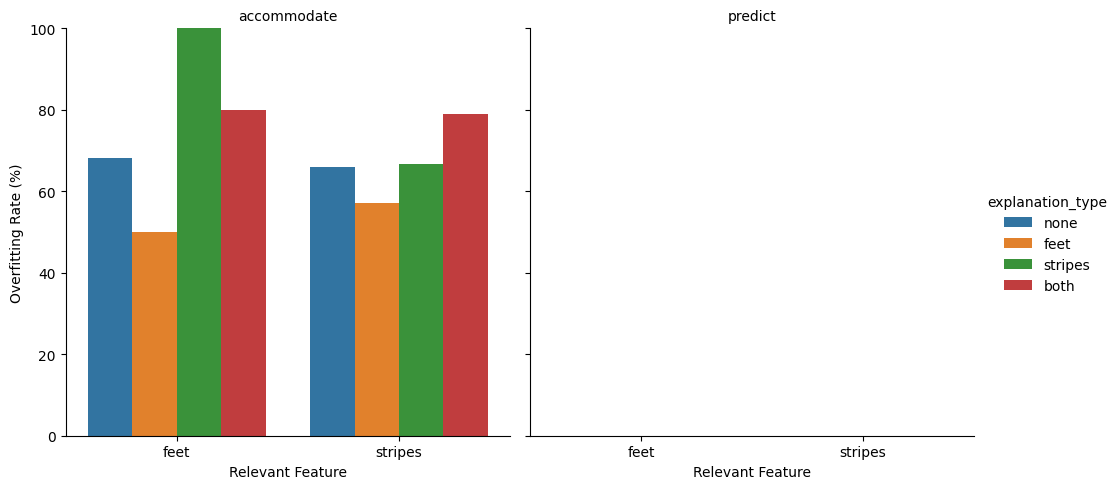

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summarize from participant-level data
overfit_summary = (
    participant_level
    .groupby(['task', 'explanation_type', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

# Plot
g = sns.catplot(
    data=overfit_summary,
    x='irrelevant_dim',
    y='overfit_percent',
    hue='explanation_type',
    col='task',
    kind='bar',
    height=5,
    aspect=1
)

g.set_axis_labels('Relevant Feature', 'Overfitting Rate (%)')
g.set_titles('{col_name}')
g.set(ylim=(0, 100))

for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/2283128469.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/2283128469.py:52: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/2283128469.py:52: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


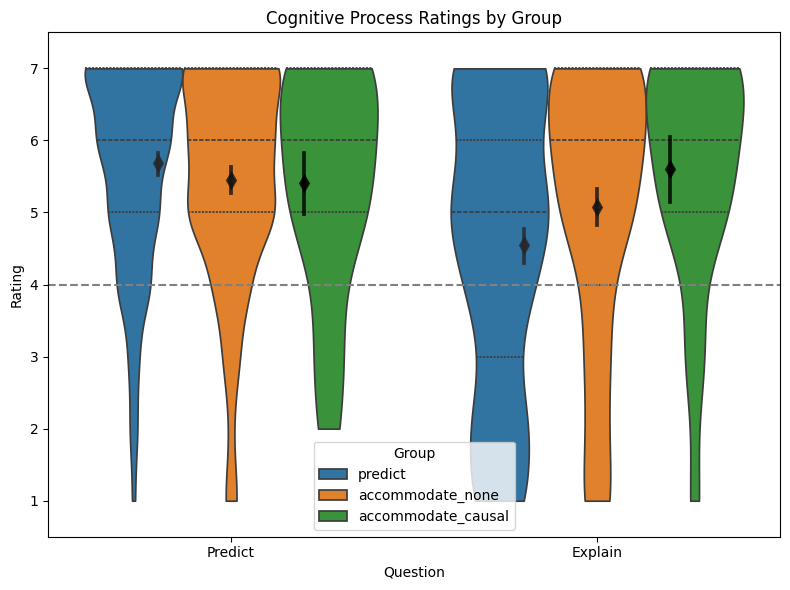

In [15]:

df_combined["has_causal_explanation"] = (
    df_combined["has_causal_explanation"]
    .fillna(False)
    .astype(bool)
)

df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        df_combined["task"].eq("accommodate") & df_combined["has_causal_explanation"],
        df_combined["task"].eq("accommodate") & ~df_combined["has_causal_explanation"],
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default="missing"
)

df_cogpro_long = df_combined.melt(
    id_vars=["participant", "task", "task_explanation_group"],
    value_vars=["cogpro_predict", "cogpro_explain"],
    var_name="question",
    value_name="rating"
)

df_cogpro_long["question"] = df_cogpro_long["question"].replace({
    "cogpro_predict": "Predict",
    "cogpro_explain": "Explain"
})

df_cogpro_long["task_explanation_group"] = pd.Categorical(
    df_cogpro_long["task_explanation_group"],
    categories=["predict", "accommodate_none", "accommodate_causal"],
    ordered=True
)

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df_cogpro_long,
    x="question",
    y="rating",
    hue="task_explanation_group",
    dodge=True,
    cut=0,
    inner="quartile",
    density_norm="width"
)

sns.pointplot(
    data=df_cogpro_long,
    x="question",
    y="rating",
    hue="task_explanation_group",
    dodge=.4,
    join=False,
    markers="d",
    errorbar=("ci", 95),
    color="black",
    alpha=.8,
    legend=False
)

plt.ylim(.5, 7.5)
plt.axhline(4, color="gray", linestyle="--")
plt.title("Cognitive Process Ratings by Group")
plt.ylabel("Rating")
plt.xlabel("Question")

# remove duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Group")

plt.tight_layout()
plt.show()

In [16]:
#Create map from short codes to feature descriptions

feet_map = {
    'webbed': 'f',
    'curved/pointy': 'c'
}

stripes_map = {
    'up/right': 'e',
    'up/left': 'w'
}



feature_maps = {
    'feet': feet_map,
    'stripes': stripes_map
}


#Compute feature importance scores

from doctest import debug


#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'stripes']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)

# Create 3-level group:
# predict
# accommodate_none
# accommodate_causal
df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        df_combined["task"].eq("accommodate") & df_combined["has_causal_explanation"].eq(True),
        df_combined["task"].eq("accommodate") & df_combined["has_causal_explanation"].eq(False),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default="missing",
)
df_combined["task_explanation_group"] = df_combined["task_explanation_group"].replace(
    "missing", pd.NA
)
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    "participant", "task", "task_explanation_group",
    "feet_importance", "stripes_importance", 
    "explanation_type", "has_causal_explanation",
    "relevant_dim", "irrelevant_dim", 
    "feet_high", "stripes_high", 
    "feet_discrete_slider.response"
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant", "task", "task_explanation_group",
        "explanation_type", "has_causal_explanation",
        "relevant_dim", "irrelevant_dim",
        "stripes_high", "feet_high",
        "feet_discrete_slider.response"
    ],
    value_vars=["feet_importance", "stripes_importance"],
    var_name="feature_dimension",
    value_name="feature_importance"
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)


response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/972398585.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/972398585.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/972398585.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


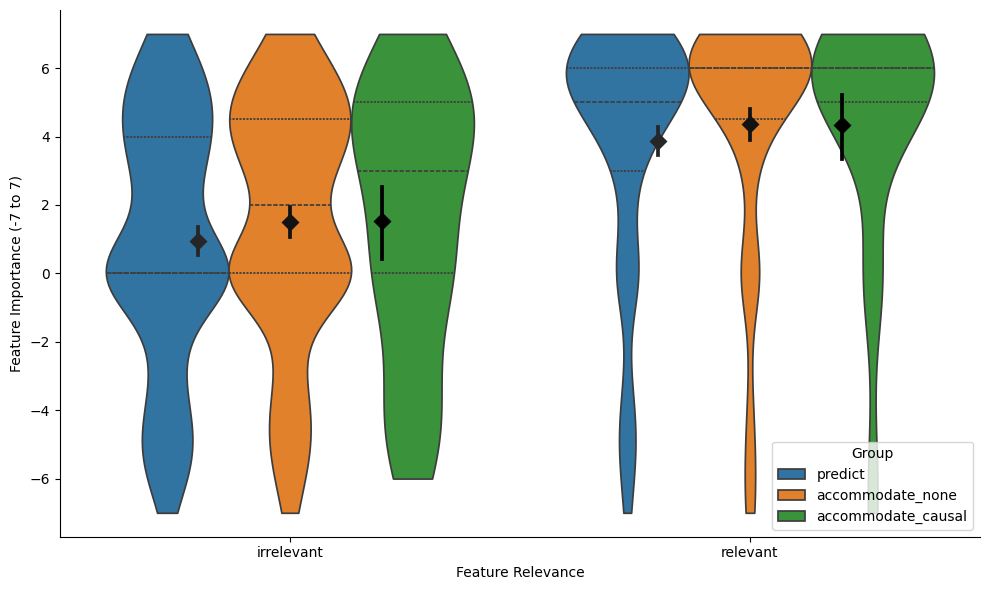

In [17]:
df_long["feature_dimension"] = df_long["feature_dimension"].str.replace("_importance", "")

df_long["feature_relevance"] = df_long.apply(
    lambda row: "relevant" if row["feature_dimension"] == row["relevant_dim"] else "irrelevant",
    axis=1
)

df_long["feature_relevance"] = pd.Categorical(
    df_long["feature_relevance"],
    categories=["irrelevant", "relevant"],
    ordered=True
)

df_long["task_explanation_group"] = pd.Categorical(
    df_long["task_explanation_group"],
    categories=["predict", "accommodate_none", "accommodate_causal"],
    ordered=True
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long,
    x="feature_relevance",
    y="feature_importance",
    hue="task_explanation_group",
    inner="quartile",
    cut=0,
    scale="width"
)

# Overlay means + 95% CI
sns.pointplot(
    data=df_long,
    x="feature_relevance",
    y="feature_importance",
    hue="task_explanation_group",
    dodge=0.4,
    join=False,
    markers="D",
    errorbar=("ci", 95),
    color="black",
    legend=False
)

sns.despine()
plt.ylabel("Feature Importance (-7 to 7)")
plt.xlabel("Feature Relevance")

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Group", loc="lower right")

plt.tight_layout()
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/3531464586.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/3531464586.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/3531464586.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


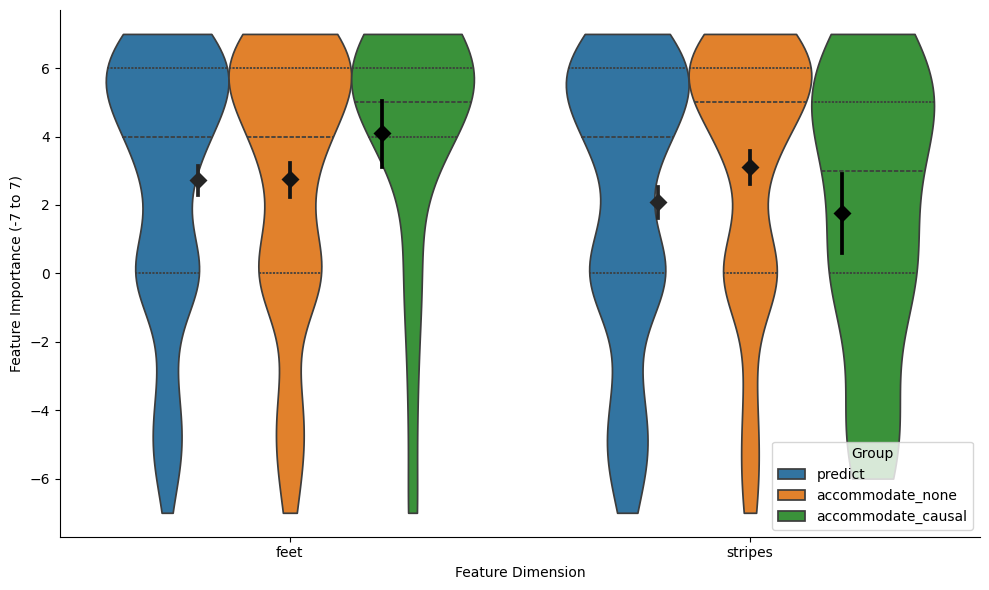

In [18]:
df_long["feature_dimension"] = df_long["feature_dimension"].str.replace("_importance", "")

df_long["feature_relevance"] = df_long.apply(
    lambda row: "relevant" if row["feature_dimension"] == row["relevant_dim"] else "irrelevant",
    axis=1
)

df_long["feature_relevance"] = pd.Categorical(
    df_long["feature_relevance"],
    categories=["irrelevant", "relevant"],
    ordered=True
)

df_long["task_explanation_group"] = pd.Categorical(
    df_long["task_explanation_group"],
    categories=["predict", "accommodate_none", "accommodate_causal"],
    ordered=True
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long,
    x="feature_dimension",
    y="feature_importance",
    hue="task_explanation_group",
    inner="quartile",
    cut=0,
    scale="width"
)

# Overlay means + 95% CI
sns.pointplot(
    data=df_long,
    x="feature_dimension",
    y="feature_importance",
    hue="task_explanation_group",
    dodge=0.4,
    join=False,
    markers="D",
    errorbar=("ci", 95),
    color="black",
    legend=False
)

sns.despine()
plt.ylabel("Feature Importance (-7 to 7)")
plt.xlabel("Feature Dimension")

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Group", loc="lower right")

plt.tight_layout()
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/4176507243.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


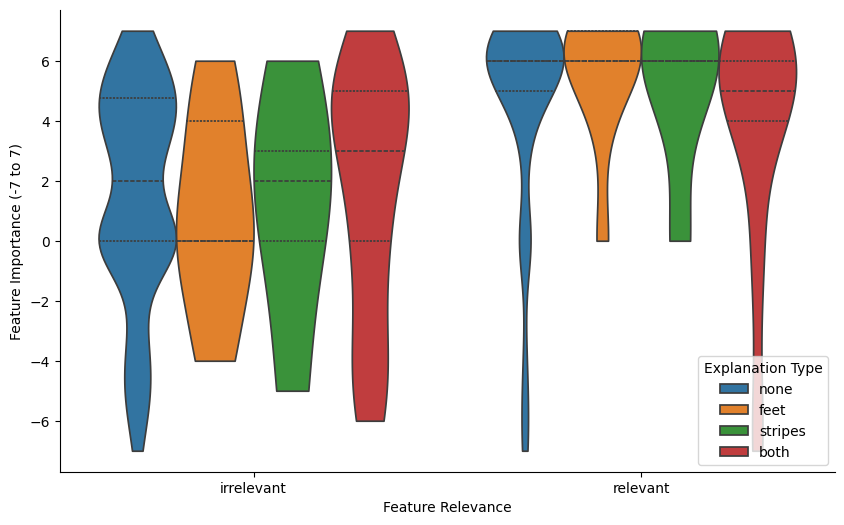

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_relevance'] = pd.Categorical(
    df_long_acc['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

df_long_acc['explanation_type'] = pd.Categorical(
    df_long_acc['explanation_type'],
    categories=['none', 'feet', 'stripes', 'both'],
    ordered=False
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long_acc,
    x='feature_relevance',
    y='feature_importance',
    hue='explanation_type',
    inner='quartile',
    cut=0,
    scale='width'
)

sns.despine()
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Explanation Type', loc='lower right')
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_7260/829814774.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


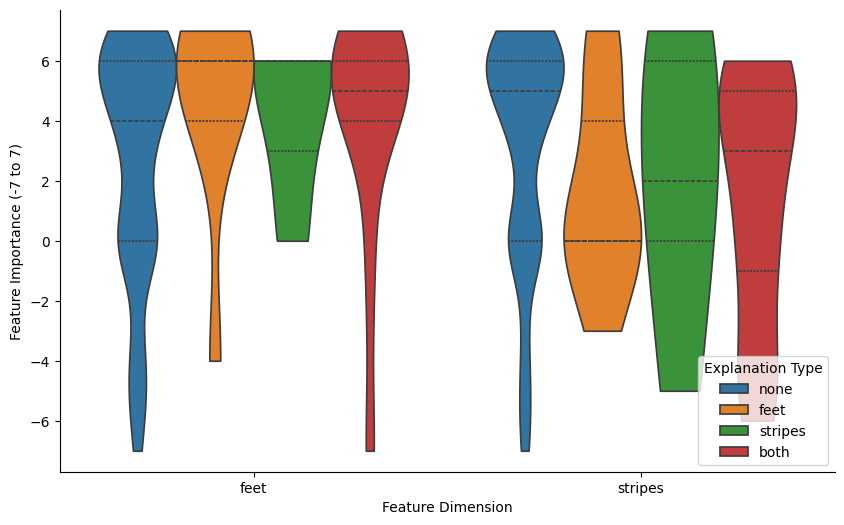

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_dimension'] = pd.Categorical(
    df_long_acc['feature_dimension'],
    categories=['feet', 'stripes'],
    ordered=False
)

df_long_acc['explanation_type'] = pd.Categorical(
    df_long_acc['explanation_type'],
    categories=['none', 'feet', 'stripes', 'both'],
    ordered=False
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long_acc,
    x='feature_dimension',
    y='feature_importance',
    hue='explanation_type',
    inner='quartile',
    cut=0,
    scale='width'
)

sns.despine()
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Dimension')
plt.legend(title='Explanation Type', loc='lower right')
plt.show()

In [22]:
print(df_long_acc)

     participant         task task_explanation_group explanation_type  \
0            226  accommodate       accommodate_none             none   
1            210  accommodate       accommodate_none             none   
2            269  accommodate     accommodate_causal             both   
3            215  accommodate       accommodate_none             none   
4             83  accommodate       accommodate_none             none   
..           ...          ...                    ...              ...   
874          144  accommodate       accommodate_none             none   
875            8  accommodate       accommodate_none             none   
876          167  accommodate       accommodate_none             none   
877           28  accommodate       accommodate_none             none   
878          154  accommodate       accommodate_none             none   

     has_causal_explanation relevant_dim irrelevant_dim stripes_high  \
0                     False      stripes           

In [25]:
print(df_combined)

     participant                                         free_texts  \
0            226  [This reptile presents with stripes that move ...   
1            210  [It has produced many offsprings, Few offsprin...   
2            269  [The webbed toes are not efficient for a tree ...   
3            215  [Presumably this reptile received a high ferti...   
4             83  [The reptile may have low viability of hatchli...   
..           ...                                                ...   
581          235                                                NaN   
582           78                                                NaN   
583          197                                                NaN   
584          265                                                NaN   
585           86                                                NaN   

                                              feedback  \
0    ['There did not appear to be sufficient inform...   
1                              

In [35]:
#Group by average food amount per item in training
df = df_combined[['task', 'explanation_type',  'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'explanation_type', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.tail(200))
#Get food consumption ratings by item

df = df_combined[['task', 'explanation_type', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)

#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'explanation_type', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['stripes', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

             task explanation_type  conditionOrder item fertility_score
972   accommodate             none             246  E_C            3.25
973   accommodate             none             246  E_F             2.5
974   accommodate             none             246  W_C            8.75
975   accommodate             none             246  W_F             6.0
976   accommodate             none             247  E_C            4.25
...           ...              ...             ...  ...             ...
1167  accommodate          stripes             255  W_F             7.5
1168  accommodate          stripes             286  E_C             3.0
1169  accommodate          stripes             286  E_F             4.5
1170  accommodate          stripes             286  W_C             7.5
1171  accommodate          stripes             286  W_F             9.0

[200 rows x 5 columns]
            task explanation_type  conditionOrder item testing_responses  \
0    accommodate             none   

In [37]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['stripes_match_high']  = (df_merged['stripes']  == df_merged['stripes_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['stripes','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'explanation_type': g['explanation_type'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



         participant     task explanation_type feature_dimension high_value  \
1132  (predict, 280)  predict              NaN           stripes          E   
1133  (predict, 280)  predict              NaN              feet          F   
1134  (predict, 281)  predict              NaN           stripes          E   
1135  (predict, 281)  predict              NaN              feet          C   
1136  (predict, 282)  predict              NaN           stripes          W   
1137  (predict, 282)  predict              NaN              feet          F   
1138  (predict, 283)  predict              NaN           stripes          W   
1139  (predict, 283)  predict              NaN              feet          F   
1140  (predict, 285)  predict              NaN           stripes          E   
1141  (predict, 285)  predict              NaN              feet          C   
1142  (predict, 286)  predict              NaN           stripes          W   
1143  (predict, 286)  predict              NaN      

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


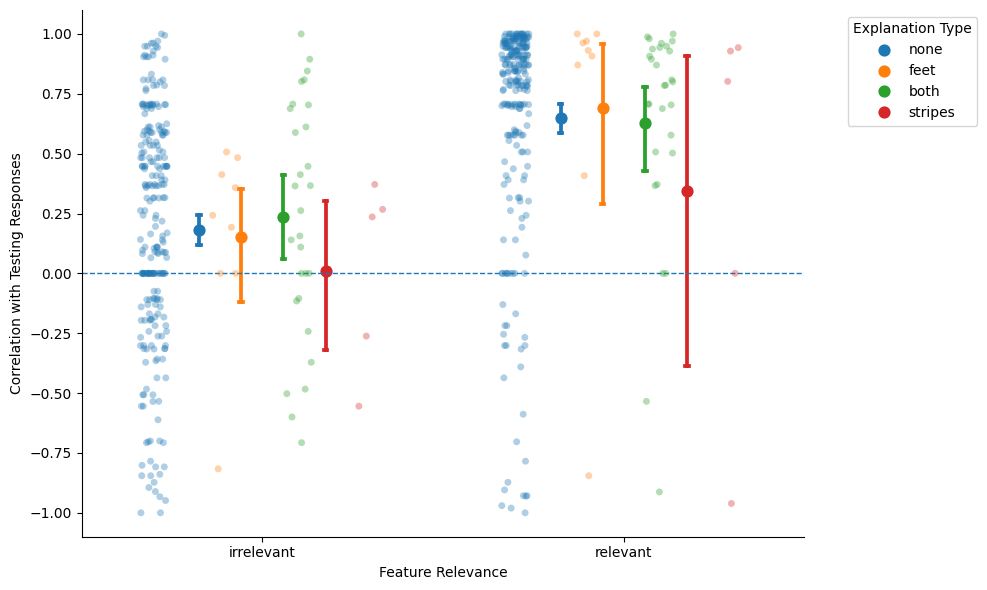

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_corr.copy()

plt.figure(figsize=(10, 6))

sns.pointplot(
    data=plot_df,
    x='feature_relevance',
    y='correlation',
    hue='explanation_type',
    errorbar=('ci', 95),
    dodge=0.35,
    markers='o',
    linestyle='none',
    capsize=.01
)

sns.stripplot(
    data=plot_df,
    x='feature_relevance',
    y='correlation',
    hue='explanation_type',
    dodge=True,
    alpha=.35,
    jitter=.15,
    legend=False
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Feature Relevance")
plt.ylabel("Correlation with Testing Responses")
plt.legend(title="Explanation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

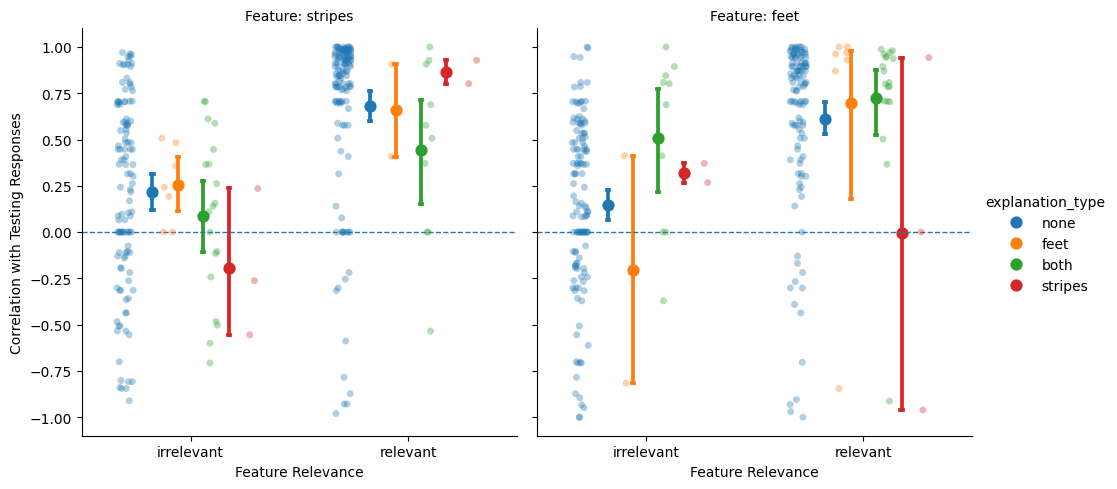

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=plot_df,
    x='feature_relevance',
    y='correlation',
    hue='explanation_type',
    col='feature_dimension',
    kind='point',
    errorbar=('ci', 95),
    dodge=0.35,
    markers='o',
    linestyle='none',
    capsize=.01,
    height=5,
    aspect=1
)

# Add stripplots to each facet
for ax, feat in zip(g.axes.flat, plot_df['feature_dimension'].unique()):

    sns.stripplot(
        data=plot_df[plot_df['feature_dimension'] == feat],
        x='feature_relevance',
        y='correlation',
        hue='explanation_type',
        dodge=True,
        alpha=.35,
        jitter=.15,
        legend=False,
        ax=ax
    )

    ax.axhline(0, linestyle='--', linewidth=1)

g.set_axis_labels(
    "Feature Relevance",
    "Correlation with Testing Responses"
)

g.set_titles("Feature: {col_name}")

sns.despine()
plt.show()

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_relevance'] = pd.Categorical(
    df_long_acc['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

df_long_acc['functional_type'] = pd.Categorical(
    df_long_acc['functional_type'],
    categories=['none', 'feet_only', 'color_only', 'both'],
    ordered=False
)

df_long_acc['relevant_dim'] = pd.Categorical(
    df_long_acc['relevant_dim'],
    categories=['feet', 'color'],
    ordered=False
)

g = sns.catplot(
    data=df_long_acc,
    x='feature_relevance',
    y='feature_importance',
    hue='functional_type',
    col='relevant_dim',
    kind='violin',
    inner='quartile',
    cut=0,
    scale='width',
    height=5,
    aspect=1
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.set_titles('Relevant feature: {col_name}')

for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

KeyError: 'functional_type'

In [43]:
means = (
    df_long
    .groupby(["task", "feature_relevance"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


                     task feature_relevance      mean       std  count
0             accommodate        irrelevant  1.073333  3.643688    150
1             accommodate          relevant  3.353333  3.625296    150
2  accommodate_functional        irrelevant  1.194030  3.290200     67
3  accommodate_functional          relevant  4.567164  2.818897     67
4                 predict        irrelevant  1.087558  2.900620    217
5                 predict          relevant  2.935484  3.432616    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/1213789995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["feature_importance"]


In [47]:
import statsmodels.formula.api as smf
df_long['task'] = pd.Categorical(
    df_long['task'],
    categories=['accommodate', 'accommodate_functional', 'predict']
)

df_long['feature_relevance'] = pd.Categorical(
    df_long['feature_relevance'],
    categories=['irrelevant', 'relevant']
)
# Predicting feature importance from task and feature relevance, with random intercepts for participants
md = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"],  # random intercept per participant
    re_formula="~feature_relevance" # random slopes
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_featureimportance.csv"))

                                 Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              feature_importance
No. Observations:              868                  Method:                          REML              
No. Groups:                    217                  Scale:                           9.0821            
Min. group size:               4                    Log-Likelihood:                  -2265.0976        
Max. group size:               4                    Converged:                       Yes               
Mean group size:               4.0                                                                     
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/341896458.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


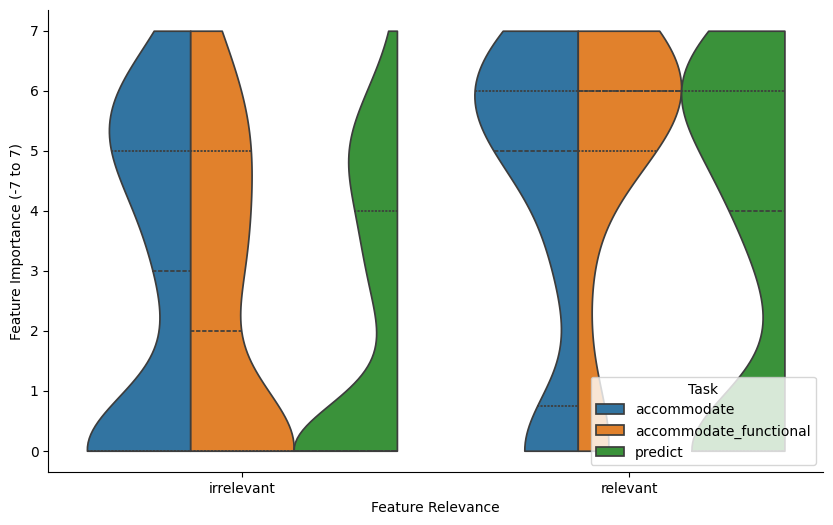

In [46]:
df_longAbs = df_long.copy()
df_longAbs["abs_feature_importance"] = df_longAbs["feature_importance"].abs()


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_longAbs['feature_relevance'] = pd.Categorical(df_longAbs['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_longAbs,
    x='feature_relevance',      # relevant / irrelevant
    y='abs_feature_importance',  # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',  
    scale = 'width',          # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.show()


In [49]:
means = (
    df_longAbs
    .groupby(["task", "feature_relevance"])["abs_feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


                     task feature_relevance      mean       std  count
0             accommodate        irrelevant  2.753333  2.608547    150
1             accommodate          relevant  4.166667  2.643002    150
2  accommodate_functional        irrelevant  2.417910  2.517510     67
3  accommodate_functional          relevant  4.776119  2.442185     67
4                 predict        irrelevant  2.046083  2.322932    217
5                 predict          relevant  3.525346  2.820322    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/4006119165.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["abs_feature_importance"]


LABELS

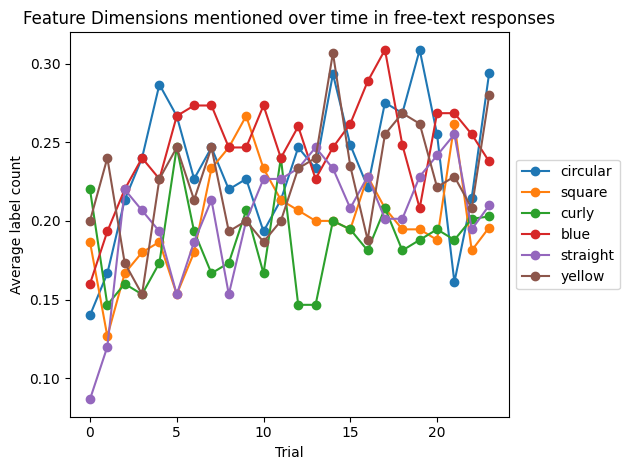

In [33]:
def count_labels_over_time(free_text_list, word_labels):
    """
    free_text_list: list of free-text responses (strings) in order
    word_labels: dict mapping label -> list of words
    Returns a list of dicts (one per trial) with counts per label
    """
    counts_over_time = []

    for text in free_text_list:
        text_lower = text.lower()  # lowercase 
        counts = {label: 0 for label in word_labels}

        for label, words in word_labels.items():
            for word in words:
                counts[label] += text_lower.count(word)  # count occurrences
        counts_over_time.append(counts)

    return counts_over_time


word_labels = {
    'circular': ['circle', 'circular', 'oval', 'round'],
    'square': ['square', 'squared', 'rectangle', 'rectangular'],
    'curly': ['curly'],
    'straight': ['straight'],
    'blue': ['blue'],
    'yellow': ['yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    
    counts = count_labels_over_time(free_text_list, word_labels)
    
    # Add participant ID and timepoint
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

# Convert to DataFrame for analysis
df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['circular','square','curly', 'blue', 'straight', 'yellow']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()


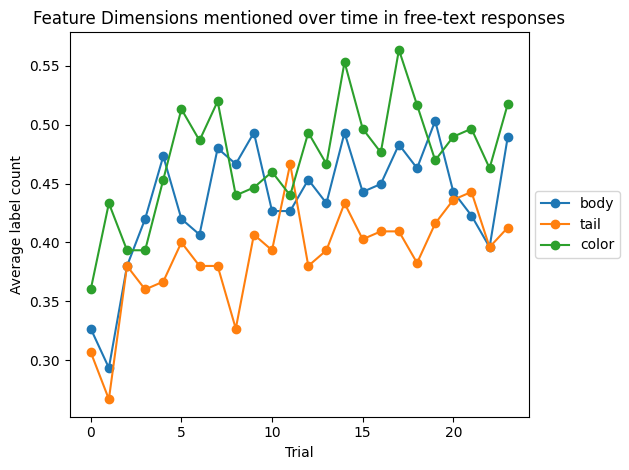

In [35]:
word_labels = {
    'body': ['circle', 'circular', 'oval', 'round', 'square', 'squared', 'rectangle', 'rectangular'],
    'tail': ['curly', 'straight'],
    'color': ['blue', 'yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    
    counts = count_labels_over_time(free_text_list, word_labels)
    
    # Add participant ID and timepoint
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

# Convert to DataFrame for analysis
df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['body', 'tail', 'color']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()

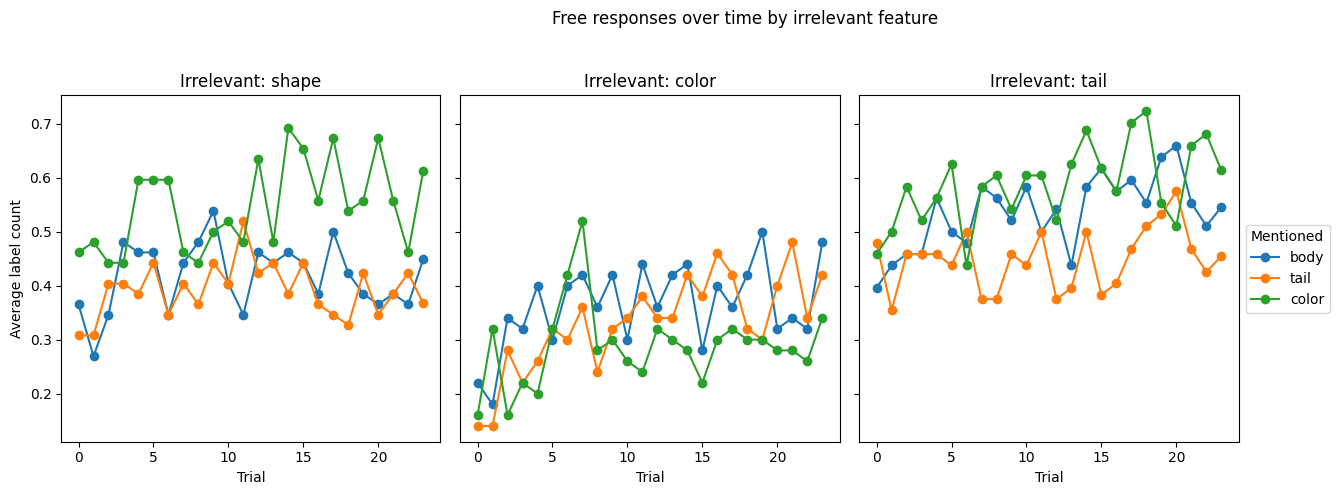

In [ ]:
def analyze_free_text_labels(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    task_name: just for plot titles
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Add participant ID, trial, and irrelevant_dim
        for trial, count_dict in enumerate(counts):
            count_dict.update({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature
            })
            all_counts.append(count_dict)

    # Convert to DataFrame
    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature
    labels = list(word_labels.keys())
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')[labels].mean()
        df_grouped.plot(ax=ax, marker='o', legend=False)
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average label count')

    plt.suptitle('Free responses over time by irrelevant feature')
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Mentioned')
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave space for suptitle
    plt.show()

    return df_counts
df_counts = analyze_free_text_labels(df_accommodate, word_labels)


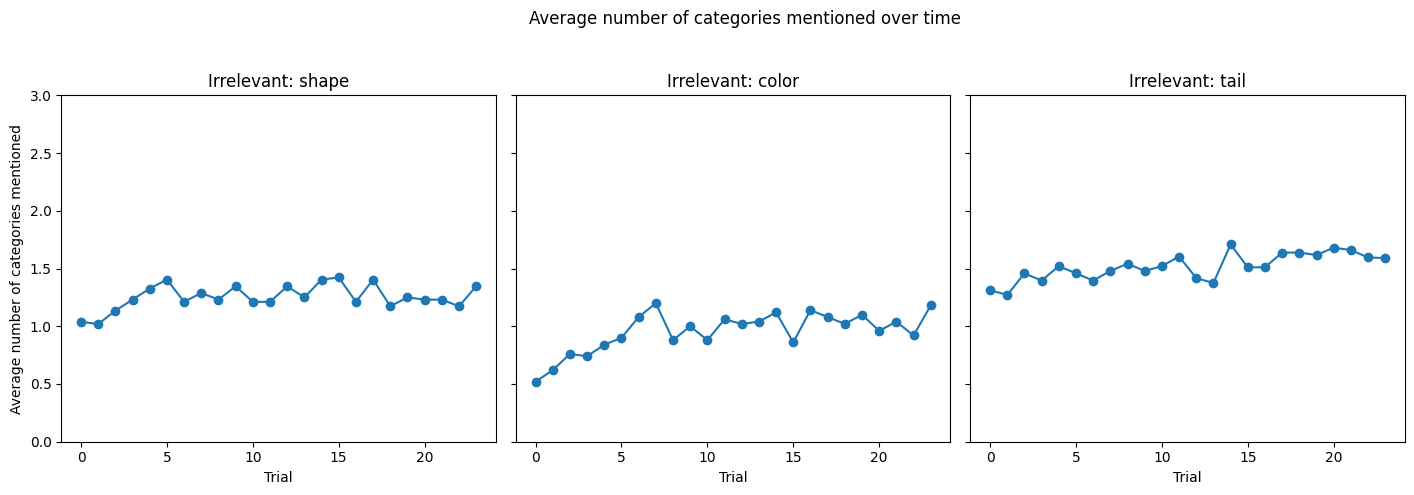

In [36]:
def analyze_free_text_num_mentions(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    Returns: df_counts with number of categories mentioned per trial and plots 0-3 mentions over time
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Convert counts into number of categories mentioned (0-3)
        for trial, count_dict in enumerate(counts):
            num_mentions = sum([1 for lbl in word_labels if count_dict[lbl] > 0])
            all_counts.append({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature,
                'num_mentions': num_mentions
            })

    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature (0-3 mentions)
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')['num_mentions'].mean()
        df_grouped.plot(ax=ax, marker='o', linestyle='-')
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average number of categories mentioned')
        ax.set_ylim(0, 3)  # 0-3 mentions possible

    plt.suptitle('Average number of categories mentioned over time')
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()

    return df_counts
df_counts = analyze_free_text_num_mentions(df_accommodate, word_labels)

In [ ]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'food_amount', 'conditionOrder', 'color_high', 'tail_high', 'shape_high', 'irrelevant_dim', 
                  'tail_importance', 'color_importance', 'shape_importance']]
df_long3 = (
    df
    .explode(['training_image_order', 'food_amount'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food_extended = (
    df_long3
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    .agg(
        food_amount=('food_amount', 'mean'),
        color_high=('color_high', 'first'),
        tail_high=('tail_high', 'first'),
        shape_high=('shape_high', 'first'),
        irrelevant_dim=('irrelevant_dim', 'first')
    )
)

avg_food_train_extended = avg_food_extended.copy()

df = avg_food_train_extended.copy()

#print(df)
df['high_or_low'] = df.apply(
    lambda row: 'high' if row[f"{row['irrelevant_dim']}_high"] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)
def get_irrelevant_value(row):
    tail, color, shape = row['item'].split('_')
    if row['irrelevant_dim'] == 'tail':
        return tail
    elif row['irrelevant_dim'] == 'color':
        return color
    elif row['irrelevant_dim'] == 'shape':
        return shape
    else:
        return None

df['irrelevant_value'] = df.apply(get_irrelevant_value, axis=1)

# Quick check
#print(df[['item', 'irrelevant_dim', 'irrelevant_value', 'tail_high', 'color_high', 'shape_high']].head(20))
df['high_or_low'] = df.apply(
    lambda row: 'high' if row['irrelevant_value'] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)

# Debug
#print(df[['item', 'irrelevant_dim', 'irrelevant_value', 'high_or_low']].head(20))
# Compute high vs low difference
high_low_diff = (
    df.groupby(['task', 'conditionOrder', 'irrelevant_dim', 'high_or_low'])['food_amount']
      .mean()             # average food amount per high/low
      .unstack(fill_value=0)  # columns become 'high' and 'low'; missing = 0
)

# Compute high_minus_low
high_low_diff['high_minus_low'] = high_low_diff['high'] - high_low_diff['low']

# Reset index for a clean table
high_low_diff = high_low_diff.reset_index()

print(high_low_diff[['task', 'conditionOrder', 'irrelevant_dim', 'high_minus_low']])



In [ ]:
import pandas as pd

# Get Relevant Columns
df = df_combined[['task', 'training_image_order', 'food_amount', 'conditionOrder',
                  'color_high', 'tail_high', 'shape_high', 'irrelevant_dim',
                  'tail_importance', 'color_importance', 'shape_importance']]

# Explode lists into rows
df_long = df.explode(['training_image_order', 'food_amount']).rename(columns={'training_image_order': 'item'})

# 3️Compute mean food amount per item
df_items = (
    df_long.groupby(['task', 'conditionOrder', 'item'], as_index=False)
           .agg(
               food_amount=('food_amount', 'mean'),
               color_high=('color_high', 'first'),
               tail_high=('tail_high', 'first'),
               shape_high=('shape_high', 'first'),
               irrelevant_dim=('irrelevant_dim', 'first'),
               tail_importance=('tail_importance', 'first'),
               color_importance=('color_importance', 'first'),
               shape_importance=('shape_importance', 'first')
           )
)

# Extract actual value of the irrelevant dimension from the item
def get_irrelevant_value(row):
    tail, color, shape = row['item'].split('_')
    if row['irrelevant_dim'] == 'tail':
        return tail
    elif row['irrelevant_dim'] == 'color':
        return color
    elif row['irrelevant_dim'] == 'shape':
        return shape

df_items['irrelevant_value'] = df_items.apply(get_irrelevant_value, axis=1)

# Determine if each item is high or low along the irrelevant dimension
df_items['high_or_low'] = df_items.apply(
    lambda row: 'high' if row['irrelevant_value'] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)

# Get importance for irrelevant feature for each item
df_items['irrelevant_importance'] = df_items.apply(
    lambda row: row[f"{row['irrelevant_dim']}_importance"], axis=1
)

# Compute high vs low differences and keep importance score
agg = (
    df_items.groupby(['task', 'conditionOrder', 'irrelevant_dim', 'high_or_low'])
            .agg(
                food_amount_mean=('food_amount', 'mean'),
                irrelevant_importance_mean=('irrelevant_importance', 'mean')
            )
            .unstack(fill_value=0)  # separate 'high' and 'low'
)

# Compute high_minus_low
agg['high_minus_low'] = agg['food_amount_mean']['high'] - agg['food_amount_mean']['low']

# Get irrelevant importance
agg['irrelevant_importance'] = agg['irrelevant_importance_mean']['high']

# Reset index and select final columns
final_df = agg.reset_index()[['task', 'conditionOrder', 'irrelevant_dim', 'high_minus_low', 'irrelevant_importance']]
final_df['high_minus_low'] = pd.to_numeric(final_df['high_minus_low'], errors='coerce')
final_df['irrelevant_importance'] = pd.to_numeric(final_df['irrelevant_importance'], errors='coerce')

print(final_df.head(10))


In [ ]:
# Position-based decoding
FEATURE_INDEX = {
    "tail":  0,  # T or N
    "color": 1,  # B or Y
    "shape": 2   # S or C
}
def extract_feature(stimulus, feature):
    """
    stimulus: string like 'T_B_S'
    feature: 'tail', 'color', or 'shape'
    """
    return stimulus.split("_")[FEATURE_INDEX[feature]]
mapping = {
    "tail":  {"T": 1, "N": 0},
    "shape": {"S": 1, "C": 0},
    "color": {"B": 1, "Y": 0}
}
cols_to_keep = [
    "participant",
    "task",
    "conditionOrder",
    "irrelevant_dim",
    "food_amount",
    "training_color",
    "training_shape",
    "training_tail",
    "training_image_order",
    "tail_importance",
    "shape_importance",
    "color_importance"
]

def compute_true_irrelevant_assoc(row):
    irrel_feat = row["irrelevant_dim"]

    # Food values
    food = np.array(
        ast.literal_eval(row["food_amount"])
        if isinstance(row["food_amount"], str)
        else row["food_amount"],
        dtype=float
    )

    # Extract irrelevant feature value per training trial
    irrel_vals = np.array([
        mapping[irrel_feat][
            extract_feature(stim, irrel_feat)
        ]
        for stim in row["training_image_order"]
    ])

    mean_high = food[irrel_vals == 1].mean()
    mean_low  = food[irrel_vals == 0].mean()

    return mean_high - mean_low
df_irrel_truth = df_combined[cols_to_keep].copy()

df_irrel_truth["true_irrelevant_assoc"] = df_irrel_truth.apply(
    compute_true_irrelevant_assoc,
    axis=1
)

df_irrel_truth[
    ["task", "conditionOrder", "irrelevant_dim", "true_irrelevant_assoc", "color_importance", "shape_importance", "tail_importance"]
]

In [ ]:
def get_irrelevant_importance(row):
    return row[f"{row['irrelevant_dim']}_importance"]

df_plot = df_irrel_truth.copy()
df_plot["irrelevant_importance"] = df_plot.apply(
    get_irrelevant_importance, axis=1
)

plt.figure(figsize=(9, 4))

sns.scatterplot(
    data=df_plot,
    x="true_irrelevant_assoc",
    y="irrelevant_importance",
    hue="task",
    style="task",
    s=60
)

for task, sub in df_plot.groupby("task"):
    sns.regplot(
        data=sub,
        x="true_irrelevant_assoc",
        y="irrelevant_importance",
        scatter=False,
        ci=None,
        label=f"{task} fit"
    )

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel("True irrelevant association")
plt.ylabel("Irrelevant dimension rating")
plt.title("Irrelevant Dimension Rating vs True Association")
plt.legend(
    title="Task",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


